In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

backup_folder = '/content/drive/MyDrive/thesis_resnet50_outputs'
os.makedirs(backup_folder, exist_ok=True)
print(f"Backup folder ready: {backup_folder}")

Backup folder ready: /content/drive/MyDrive/thesis_resnet50_outputs


In [ ]:
import shutil
import zipfile

shutil.copy('/content/drive/MyDrive/split_dataset.zip', '/content/split_dataset.zip')

with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset restored!")
print("✅ Extract completed")
print(os.listdir('/content'))

Dataset restored!
✅ Extract completed
['.config', 'drive', 'Wheat_Yellow_Rust31.jpg', 'split_dataset.zip', 'content', 'sample_data']


In [ ]:
import pandas as pd
import os

train_df = pd.read_csv('/content/drive/MyDrive/thesis_dataset_csv/train_data.csv')
val_df = pd.read_csv('/content/drive/MyDrive/thesis_dataset_csv/val_data.csv')
test_df = pd.read_csv('/content/drive/MyDrive/thesis_dataset_csv/test_data.csv')

# Fix double-nested path (extracted zip creates /content/content/split_dataset/...)
train_df['filepath'] = train_df['filepath'].str.replace(
    '/content/split_dataset', '/content/content/split_dataset'
)
val_df['filepath'] = val_df['filepath'].str.replace(
    '/content/split_dataset', '/content/content/split_dataset'
)
test_df['filepath'] = test_df['filepath'].str.replace(
    '/content/split_dataset', '/content/content/split_dataset'
)

# Verify paths exist
print(train_df['filepath'].iloc[0])
print(os.path.exists(train_df['filepath'].iloc[0]))

class_names = sorted(train_df['label'].unique())
num_classes = len(class_names)
label_to_index = {name: idx for idx, name in enumerate(class_names)}

print("Classes:", class_names)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

/content/content/split_dataset/train/Corn_Common_Rust/Corn_Common_Rust117.JPG
True
Classes: ['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']
Train: 18037, Val: 2519, Test: 2538


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_dataset(df, shuffle=False):
    filepaths = df['filepath'].values
    labels = df['label'].map(label_to_index).values
    labels = tf.keras.utils.to_categorical(labels, num_classes=num_classes)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Datasets ready!")

Datasets ready!


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 12)        │      3,084 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,115,340 (91.99 MB)

 Trainable params: 527,628 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/thesis_resnet50_outputs/best_resnet50_model.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
)

callbacks = [early_stop, checkpoint, reduce_lr]

In [ ]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 88s 127ms/step - accuracy: 0.8394 - loss: 0.4729 - val_accuracy: 0.9107 - val_loss: 0.2454 - learning_rate: 0.0010
Epoch 2/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 61s 108ms/step - accuracy: 0.9063 - loss: 0.2600 - val_accuracy: 0.9277 - val_loss: 0.1923 - learning_rate: 0.0010
Epoch 3/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 60s 106ms/step - accuracy: 0.9296 - loss: 0.1942 - val_accuracy: 0.9464 - val_loss: 0.1484 - learning_rate: 0.0010
Epoch 4/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 89s 119ms/step - accuracy: 0.9389 - loss: 0.1638 - val_accuracy: 0.9603 - val_loss: 0.1291 - learning_rate: 0.0010
Epoch 5/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 72s 102ms/step - accuracy: 0.9491 - loss: 0.1381 - val_accuracy: 0.9551 - val_loss: 0.1373 - learning_rate: 0.0010
Epoch 6/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 58s 102ms/step - accuracy: 0.9515 - loss: 0.1322 - val_accuracy: 0.9567 - val_loss: 0.1331 - learning_rate: 0.0010
Epoch 7/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.9

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 114s 164ms/step - accuracy: 0.9437 - loss: 0.1752 - val_accuracy: 0.9722 - val_loss: 0.1081 - learning_rate: 1.0000e-05
Epoch 2/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 82s 145ms/step - accuracy: 0.9753 - loss: 0.0657 - val_accuracy: 0.9750 - val_loss: 0.0950 - learning_rate: 1.0000e-05
Epoch 3/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 79s 139ms/step - accuracy: 0.9849 - loss: 0.0453 - val_accuracy: 0.9770 - val_loss: 0.0911 - learning_rate: 1.0000e-05
Epoch 4/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 82s 140ms/step - accuracy: 0.9890 - loss: 0.0339 - val_accuracy: 0.9750 - val_loss: 0.0891 - learning_rate: 1.0000e-05
Epoch 5/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 79s 135ms/step - accuracy: 0.9920 - loss: 0.0225 - val_accuracy: 0.9746 - val_loss: 0.0950 - learning_rate: 1.0000e-05
Epoch 6/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 82s 135ms/step - accuracy: 0.9949 - loss: 0.0180 - val_accuracy: 0.9758 - val_loss: 0.0964 - learning_rate: 1.0000e-05
Epoch 7/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 78s 1

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

with open('/content/drive/MyDrive/thesis_resnet50_outputs/test_results.txt', 'w') as f:
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")

print("Test results saved to Drive!")

80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step - accuracy: 0.9775 - loss: 0.0886
Test Loss: 0.0886
Test Accuracy: 0.9775
Test results saved to Drive!


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

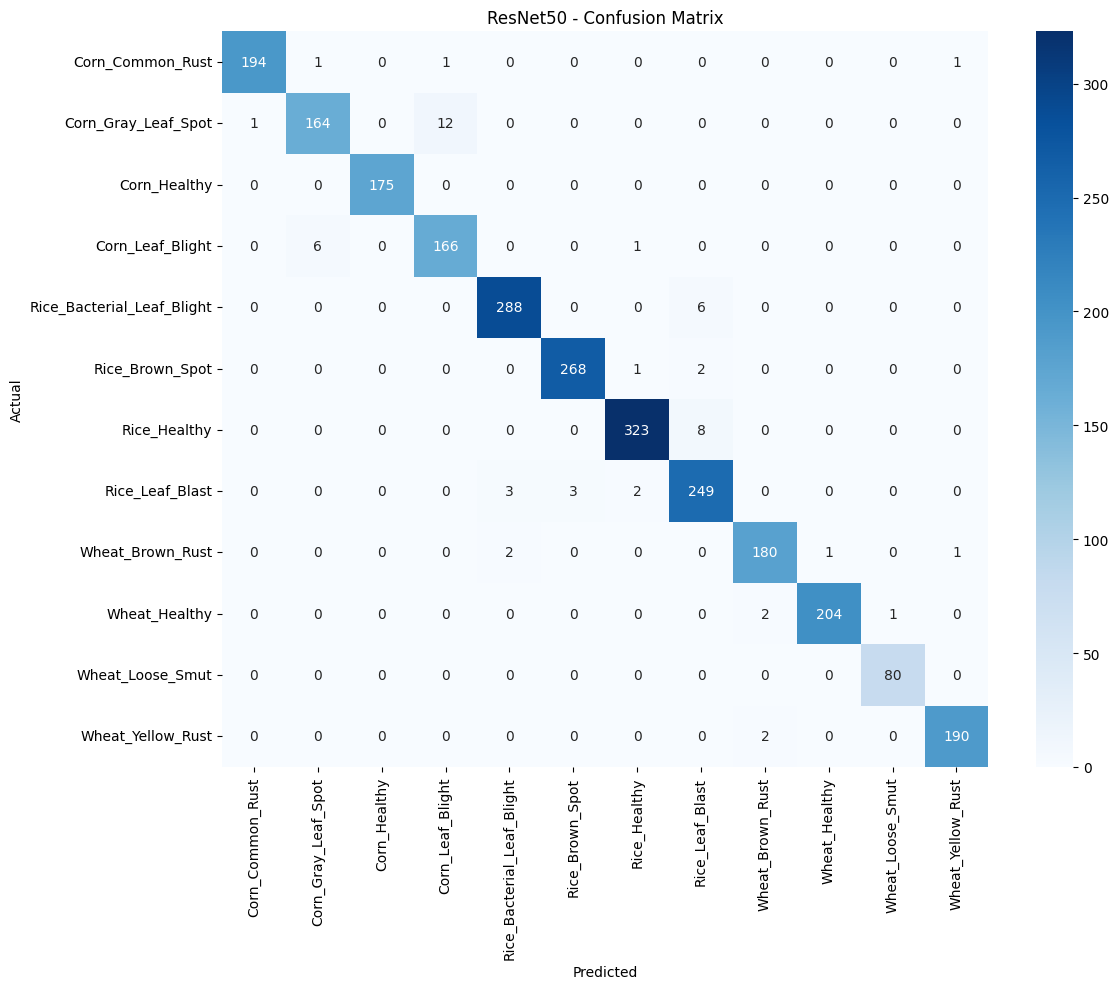

Classification report and confusion matrix saved to Drive!


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

with open('/content/drive/MyDrive/thesis_resnet50_outputs/classification_report.txt', 'w') as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ResNet50 - Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_resnet50_outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Classification report and confusion matrix saved to Drive!")

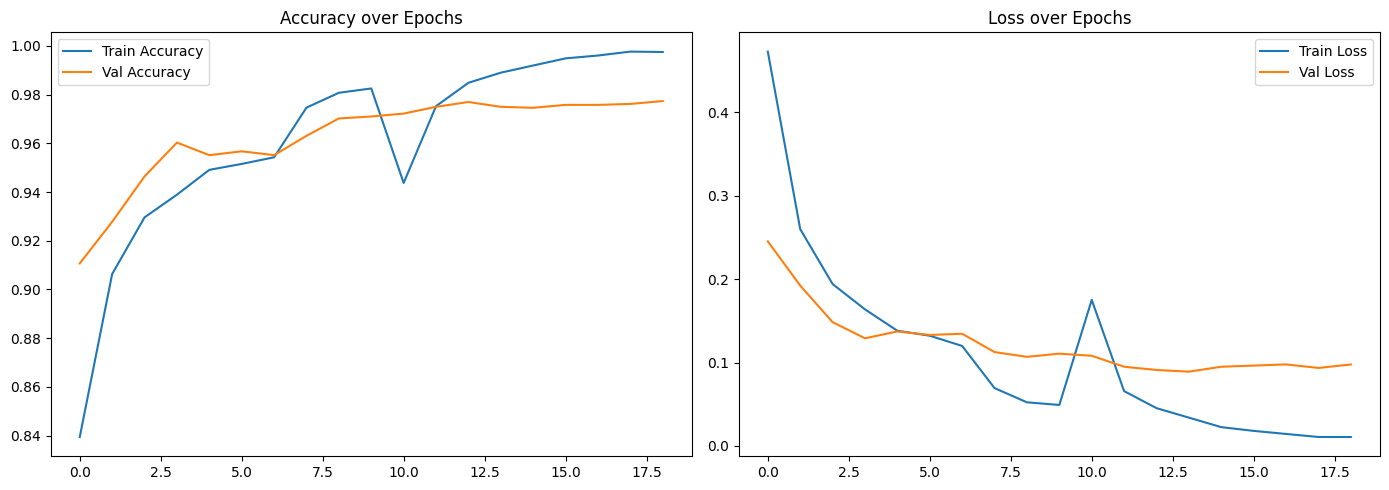

Training history plot saved to Drive!


In [ ]:
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_resnet50_outputs/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training history plot saved to Drive!")

In [ ]:
# ============================================================
# Simple single image prediction
# ============================================================

import os
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input
from google.colab import files

# Load model
model = tf.keras.models.load_model('/content/drive/MyDrive/thesis_resnet50_outputs/best_resnet50_model.keras')

# Class names (same order as training)
train_path = '/content/content/split_dataset/train'
class_names = sorted([
    cls for cls in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, cls)) and len(os.listdir(os.path.join(train_path, cls))) > 0
])

# Upload and predict
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

preds = model.predict(img_array, verbose=0)[0]
predicted_class = class_names[np.argmax(preds)]
confidence = np.max(preds) * 100

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

Saving Wheat_Yellow_Rust31.jpg to Wheat_Yellow_Rust31.jpg
Predicted class: Wheat_Yellow_Rust
Confidence: 99.59%


In [ ]:
import subprocess
result = subprocess.run(['find', '/content/drive/MyDrive', '-iname', '*split_dataset*'],
                         capture_output=True, text=True)
print(result.stdout)

/content/drive/MyDrive/split_dataset.zip



In [ ]:
print(os.listdir('/content/content/split_dataset'))

['test', 'train', 'val']


In [ ]:
# ============================================================
# Full model evaluation suite (for comparing multiple models)
# Includes: model size, parameter count, inference time
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load model ---
model_path = '/content/drive/MyDrive/thesis_resnet50_outputs/best_resnet50_model.keras'
model = tf.keras.models.load_model(model_path)

# --- Class names (must match training order) ---
train_path = '/content/content/split_dataset/train'
class_names = sorted([
    cls for cls in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, cls)) and len(os.listdir(os.path.join(train_path, cls))) > 0
])



# ============================================================
# 2. Model size (MB)
# ============================================================
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"\n📦 Model file size: {model_size_mb:.2f} MB")

# ============================================================
# 3. Parameter count
# ============================================================
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"🔢 Total parameters: {total_params:,}")
print(f"🔢 Trainable parameters: {trainable_params:,}")

# ============================================================
# 4. Inference time (average per image, in ms)
# ============================================================
sample_batch = next(iter(test_ds))[0][:1]  # take 1 image
# warm-up run (first call is always slower due to graph building)
_ = model.predict(sample_batch, verbose=0)

n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = model.predict(sample_batch, verbose=0)
end = time.time()

avg_inference_ms = ((end - start) / n_runs) * 1000
print(f"⏱️ Average inference time: {avg_inference_ms:.2f} ms/image")

# ============================================================
# Summary (copy this row into your comparison table)
# ============================================================
print("\n" + "=" * 60)
print("SUMMARY FOR COMPARISON TABLE")
print("=" * 60)
print(f"Model size (MB):       {model_size_mb:.2f}")
print(f"Total parameters:      {total_params:,}")
print(f"Inference time (ms):   {avg_inference_ms:.2f}")


📦 Model file size: 206.92 MB
🔢 Total parameters: 24,115,340
🔢 Trainable parameters: 14,977,804
⏱️ Average inference time: 84.98 ms/image

SUMMARY FOR COMPARISON TABLE
Model size (MB):       206.92
Total parameters:      24,115,340
Inference time (ms):   84.98
